# DBSCAN — scikit-learn vs scratch (exclude_self)
**Pipeline complet :**
- Chargement + preprocess (RobustScaler + PCA var=0.95)
- Échantillonnage stratifié géométrique (search + validation)
- Param search DBSCAN (sur petit échantillon search)
- Validation (sur petit échantillon validation)
- Analyse distribution tailles de clusters (anti "1 cluster énorme") —
- Visualisation côte à côte (subplot) — 

Dépendances:
```bash
pip install numpy pandas scikit-learn matplotlib
```

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, pairwise_distances

warnings.filterwarnings("ignore")
np.random.seed(42)

## 1) CONFIG

In [2]:
CSV_PATH = r"C:\Users\Y A N I S\Desktop\set\output\unbalanced_clean.csv"
CSV_SEP = ";"
SEED = 42

columns_to_exclude = ['acq_date', 'X', 'Y', 'confidence', 'fire', 'type', 'tmax', 'TEB']

# Échantillons rapides
SAMPLE_SEARCH = 8000
SAMPLE_VALIDATE = 12000
N_BINS = 200

# Preprocess
PCA_VARIANCE = 0.95

# DBSCAN
METRIC = "manhattan"
MIN_SAMPLES_GRID = [5, 8, 10, 12, 15, 20]
EPS_QUANTILES = [0.70, 0.75, 0.80, 0.85, 0.90]

# Contraintes "peu de bruit"
NOISE_MAX = 20.0
MIN_CLUSTERS_REQUIRED = 2

# Dunn approx (rapide)
DUNN_MAX_PTS_PER_CLUSTER = 150

# Visualisation
MAX_PLOT_POINTS = 12000  # downsample uniquement pour la figure

## 2) Sampling stratifié géométrique

In [3]:
def geometric_stratified_sample(X, n, n_bins=200, seed=42):
    rng = np.random.default_rng(seed)
    n = min(n, X.shape[0])

    km = MiniBatchKMeans(
        n_clusters=n_bins,
        random_state=seed,
        batch_size=2048,
        n_init="auto"
    )
    bins = km.fit_predict(X)

    idx_all = np.arange(X.shape[0])
    counts = np.bincount(bins)
    probs = counts / counts.sum()

    take = np.maximum(1, (probs * n).astype(int))
    take = (take * (n / take.sum())).astype(int)

    chosen = []
    for b in range(len(counts)):
        idx_b = idx_all[bins == b]
        if idx_b.size == 0:
            continue
        t = min(take[b], idx_b.size)
        chosen.append(rng.choice(idx_b, size=t, replace=False))

    chosen = np.unique(np.concatenate(chosen)) if chosen else np.array([], dtype=int)

    if chosen.size > n:
        chosen = rng.choice(chosen, size=n, replace=False)
    elif chosen.size < n:
        missing = n - chosen.size
        rest = np.setdiff1d(idx_all, chosen, assume_unique=False)
        if rest.size > 0:
            chosen = np.concatenate([chosen, rng.choice(rest, size=min(missing, rest.size), replace=False)])

    return chosen

## 3) Métriques DBSCAN (sans DBCV)

In [4]:
def silhouette_no_noise(X, labels):
    mask = labels != -1
    if mask.sum() < 3:
        return np.nan
    labs = labels[mask]
    if len(np.unique(labs)) < 2:
        return np.nan
    return float(silhouette_score(X[mask], labs))


def dunn_index_approx(X, labels, metric="manhattan", max_pts_per_cluster=150, seed=42):
    rng = np.random.default_rng(seed)
    clusters = [c for c in np.unique(labels) if c != -1]
    if len(clusters) < 2:
        return np.nan

    samples = {}
    for c in clusters:
        idx = np.where(labels == c)[0]
        if idx.size < 2:
            continue
        take = min(max_pts_per_cluster, idx.size)
        pick = rng.choice(idx, size=take, replace=False)
        samples[c] = X[pick]

    if len(samples) < 2:
        return np.nan

    intra_max = 0.0
    for Xc in samples.values():
        Dc = pairwise_distances(Xc, metric=metric)
        intra_max = max(intra_max, float(np.max(Dc)))
    if intra_max <= 0:
        return np.nan

    inter_min = np.inf
    keys = list(samples.keys())
    for i in range(len(keys)):
        for j in range(i + 1, len(keys)):
            A = samples[keys[i]]
            B = samples[keys[j]]
            Dij = pairwise_distances(A, B, metric=metric)
            inter_min = min(inter_min, float(np.min(Dij)))

    if not np.isfinite(inter_min) or inter_min <= 0:
        return np.nan

    return float(inter_min / intra_max)


def summarize_labels(labels):
    n = labels.size
    n_noise = int(np.sum(labels == -1))
    noise_pct = 100.0 * n_noise / max(1, n)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    return n_clusters, noise_pct


def metrics_dbscan(X, labels, metric="manhattan", seed=42):
    n_clusters, noise_pct = summarize_labels(labels)
    return {
        "n_clusters": int(n_clusters),
        "noise_pct": float(noise_pct),
        "silhouette_no_noise": silhouette_no_noise(X, labels),
        "dunn_approx": dunn_index_approx(
            X, labels,
            metric=metric,
            max_pts_per_cluster=DUNN_MAX_PTS_PER_CLUSTER,
            seed=seed
        ),
    }

## 4) Param search helpers (k-distance + score)

In [5]:
def kdist_eps_candidates(X, k, metric, quantiles):
    nbrs = NearestNeighbors(n_neighbors=k, metric=metric, n_jobs=-1).fit(X)
    distances, _ = nbrs.kneighbors(X)
    kdist = np.sort(distances[:, -1])
    eps = np.unique(np.quantile(kdist, quantiles))
    return kdist, eps


def score_config(m):
    # optimise silhouette_no_noise sous contrainte de bruit et >=2 clusters
    if m["n_clusters"] < MIN_CLUSTERS_REQUIRED:
        return -999.0
    if m["noise_pct"] > NOISE_MAX:
        return -999.0

    base = m["silhouette_no_noise"]
    if not np.isfinite(base):
        base = -1.0

    if np.isfinite(m["dunn_approx"]):
        base += 0.05 * m["dunn_approx"]

    # petit bonus si bruit modéré (pas 0% et pas énorme)
    if 1.0 <= m["noise_pct"] <= 15.0:
        base += 0.01

    return float(base)

## 5) DBSCAN scikit-learn + scratch

In [6]:
def run_dbscan_sklearn(X, eps, min_samples, metric):
    t0 = time.time()
    labels = DBSCAN(
        eps=float(eps),
        min_samples=int(min_samples),
        metric=metric,
        n_jobs=-1
    ).fit_predict(X)
    return labels, time.time() - t0


def dbscan_scratch_fast(X, eps, min_samples, metric="manhattan", exclude_self=True):
    """
    Scratch DBSCAN:
    - neighbours pré-calculés (radius_neighbors)
    - expansion BFS
    """
    n = X.shape[0]
    labels = np.full(n, -1, dtype=np.int32)
    visited = np.zeros(n, dtype=bool)
    cluster_id = 0

    nn = NearestNeighbors(radius=float(eps), metric=metric, n_jobs=-1).fit(X)
    neighbors = nn.radius_neighbors(X, return_distance=False)

    for i in range(n):
        if visited[i]:
            continue
        visited[i] = True

        neigh = neighbors[i].astype(int)
        if exclude_self:
            neigh = neigh[neigh != i]

        if neigh.size < min_samples:
            continue

        labels[i] = cluster_id
        queue = list(neigh.tolist())
        qpos = 0

        while qpos < len(queue):
            p = queue[qpos]
            if not visited[p]:
                visited[p] = True
                p_neigh = neighbors[p].astype(int)
                if exclude_self:
                    p_neigh = p_neigh[p_neigh != p]
                if p_neigh.size >= min_samples:
                    queue.extend(p_neigh.tolist())

            if labels[p] == -1:
                labels[p] = cluster_id

            qpos += 1

        cluster_id += 1

    return labels

## 6) Sanity check — distribution des tailles (anti “cluster dominant”)
**Sortie console uniquement** (pas d’histogramme).

In [7]:
def cluster_size_stats(labels, name=""):
    labels = np.asarray(labels)
    mask = labels != -1
    non_noise = labels[mask]

    print("\n" + "="*90)
    print(f"📦 CLUSTER SIZE DISTRIBUTION — {name}")
    print("="*90)

    if non_noise.size == 0:
        print("⚠️ Aucun point non-bruit -> tout est bruit.")
        return None

    _, counts = np.unique(non_noise, return_counts=True)
    counts_sorted = np.sort(counts)[::-1]

    total_non_noise = counts_sorted.sum()
    k = len(counts_sorted)

    mean = counts_sorted.mean()
    std = counts_sorted.std()
    med = np.median(counts_sorted)
    mn = counts_sorted.min()
    mx = counts_sorted.max()

    top1 = counts_sorted[0] / total_non_noise * 100
    top3 = counts_sorted[:3].sum() / total_non_noise * 100 if k >= 3 else 100.0
    top5 = counts_sorted[:5].sum() / total_non_noise * 100 if k >= 5 else 100.0

    cv = std / mean if mean > 0 else np.nan

    def gini(x):
        x = np.array(x, dtype=np.float64)
        if x.size == 0:
            return np.nan
        x = np.sort(x)
        n = x.size
        cumx = np.cumsum(x)
        return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

    g = gini(counts_sorted)

    print(f"Clusters (hors bruit): {k}")
    print(f"Total points non-bruit: {total_non_noise:,}")
    print(f"Min/Median/Mean/Max: {mn:,} / {int(med):,} / {mean:,.2f} / {mx:,}")
    print(f"Std: {std:,.2f} | CV(std/mean): {cv:.3f} | Gini: {g:.3f}")
    print(f"Top1 cluster: {top1:.2f}% du non-bruit")
    print(f"Top3 clusters: {top3:.2f}% du non-bruit")
    print(f"Top5 clusters: {top5:.2f}% du non-bruit")

    for thr in [5, 10, 20, 50, 100]:
        nb_small = int(np.sum(counts_sorted < thr))
        pct_small = 100.0 * nb_small / k
        print(f"Clusters < {thr:>3}: {nb_small:>4} ({pct_small:>5.1f}%)")

    topn = min(10, k)
    print("\nTop 10 tailles (hors bruit):")
    for i in range(topn):
        print(f"  #{i+1:02d}: {counts_sorted[i]:,}")

    return counts_sorted

## 7) Visualisations inline (k-distance + subplot clusters)

In [8]:
def show_kdist_curve(kdist, title):
    plt.figure(figsize=(10, 3))
    plt.plot(kdist, linewidth=1.2)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_dbscan_side_by_side(
    X_space,
    labels_scratch,
    labels_sklearn,
    seed=42,
    max_plot=12000
):
    # PCA 2D pour visuel
    X_pca_2d = PCA(n_components=2, random_state=seed).fit_transform(X_space)

    # Downsample pour figure
    n = X_pca_2d.shape[0]
    if n > max_plot:
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=max_plot, replace=False)
        X_pca_2d = X_pca_2d[idx]
        labels_scratch = labels_scratch[idx]
        labels_sklearn = labels_sklearn[idx]

    def info(labels):
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = 100.0 * np.mean(labels == -1)
        return n_clusters, noise_pct

    c_s, noise_s = info(labels_scratch)
    c_k, noise_k = info(labels_sklearn)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    axes[0].scatter(
        X_pca_2d[:, 0], X_pca_2d[:, 1],
        c=labels_scratch,
        cmap="tab20",
        alpha=0.5,
        s=5
    )
    axes[0].set_xlabel("PCA Component 1")
    axes[0].set_ylabel("PCA Component 2")
    axes[0].set_title(f"From Scratch (DBSCAN)\nClusters: {c_s} | Bruit: {noise_s:.1f}%")
    axes[0].grid(True, alpha=0.3)

    axes[1].scatter(
        X_pca_2d[:, 0], X_pca_2d[:, 1],
        c=labels_sklearn,
        cmap="tab20",
        alpha=0.5,
        s=5
    )
    axes[1].set_xlabel("PCA Component 1")
    axes[1].set_ylabel("PCA Component 2")
    axes[1].set_title(f"Scikit-Learn (DBSCAN)\nClusters: {c_k} | Bruit: {noise_k:.1f}%")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 8) Exécution — Chargement → preprocess → sampling → search params → validation → analyses

Chargement du dataset...
✅ Dataset chargé: 583,222 lignes, 36 features

Preprocess: RobustScaler + PCA...
✅ Preprocess terminé en 0.58s | Xp=(583222, 6)

Échantillonnage stratifié géométrique (petit, rapide)...
Search sample: (8000, 6) | Validate sample: (12000, 6)

=== PARAM SEARCH (sklearn DBSCAN on tiny sample) ===


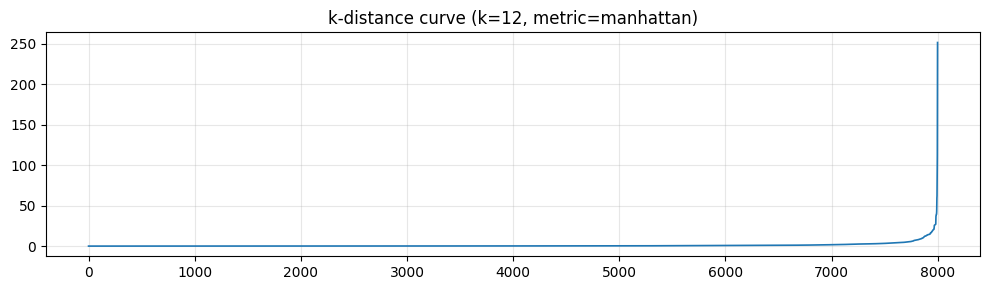


🏁 BEST CONFIG (on search sample)
eps=3.008051 | min_samples=20 | metric=manhattan | score=0.5295
{'n_clusters': 18, 'noise_pct': 6.95, 'silhouette_no_noise': 0.5172738432884216, 'dunn_approx': 0.04460422785374781, 'time_s': 0.25704360008239746, 'eps': 3.0080508485436463, 'min_samples': 20}

=== VALIDATION (SKLEARN) ===

=== VALIDATION (SCRATCH - exclude_self=True) ===

📦 CLUSTER SIZE DISTRIBUTION — SKLEARN
Clusters (hors bruit): 24
Total points non-bruit: 11,364
Min/Median/Mean/Max: 19 / 72 / 473.50 / 5,529
Std: 1,132.02 | CV(std/mean): 2.391 | Gini: 0.783
Top1 cluster: 48.65% du non-bruit
Top3 clusters: 75.43% du non-bruit
Top5 clusters: 83.83% du non-bruit
Clusters <   5:    0 (  0.0%)
Clusters <  10:    0 (  0.0%)
Clusters <  20:    1 (  4.2%)
Clusters <  50:   11 ( 45.8%)
Clusters < 100:   13 ( 54.2%)

Top 10 tailles (hors bruit):
  #01: 5,529
  #02: 1,685
  #03: 1,358
  #04: 539
  #05: 416
  #06: 400
  #07: 389
  #08: 174
  #09: 145
  #10: 139

📦 CLUSTER SIZE DISTRIBUTION — SCRAT

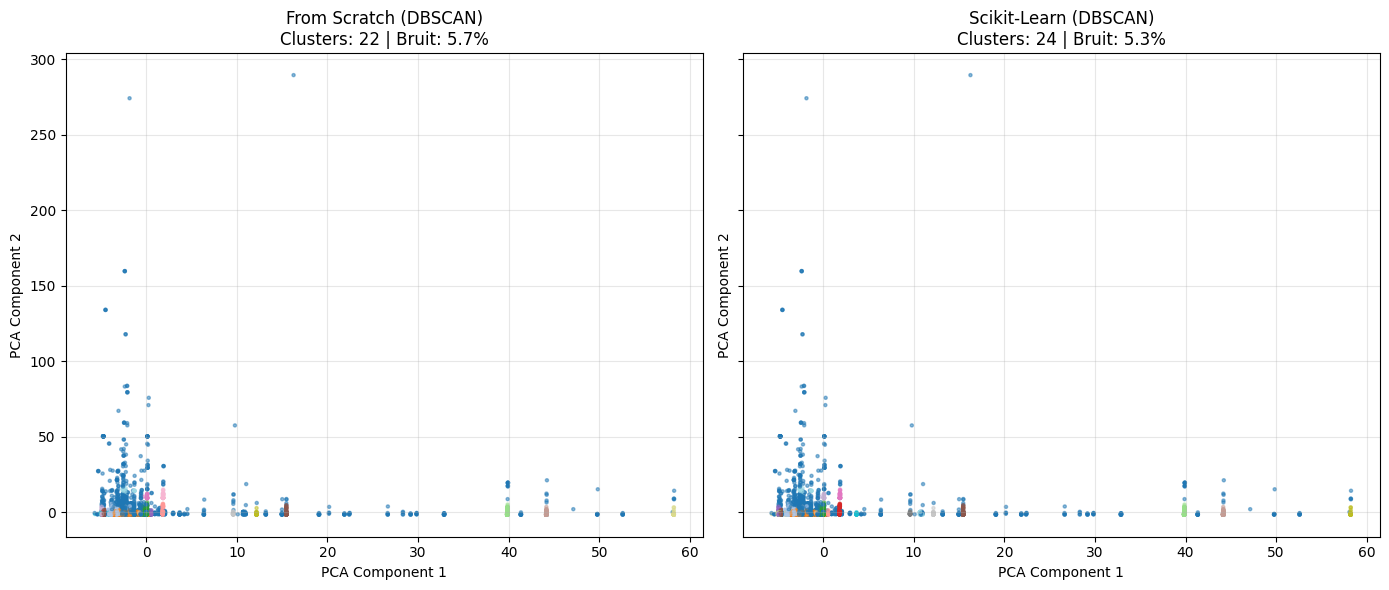


📊 DBSCAN COMPARISON (tiny stratified validation sample)
Config: eps=3.008051 | min_samples=20 | metric=manhattan
Preprocess: RobustScaler + PCA(var=0.95) | dims=6
Constraint: NOISE_MAX=20.0%
------------------------------------------------------------------------------------------
Metric                 SKLEARN              SCRATCH             
------------------------------------------------------------------------------------------
n_clusters             24                   22                  
noise_pct              5.3000               5.6667              
silhouette_no_noise    0.5141               0.5135              
dunn_approx            0.1495               0.1501              
time_s                 0.4437               5.3142              
------------------------------------------------------------------------------------------


In [9]:
print("Chargement du dataset...")
df = pd.read_csv(CSV_PATH, sep=CSV_SEP)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

feature_columns = [c for c in df.columns if c not in columns_to_exclude]
X = df[feature_columns].astype(np.float32).values
print(f"✅ Dataset chargé: {X.shape[0]:,} lignes, {X.shape[1]} features")

print("\nPreprocess: RobustScaler + PCA...")
t0 = time.time()
Xs = RobustScaler().fit_transform(X)
Xp = PCA(n_components=PCA_VARIANCE, random_state=SEED).fit_transform(Xs)
print(f"✅ Preprocess terminé en {time.time()-t0:.2f}s | Xp={Xp.shape}")

print("\nÉchantillonnage stratifié géométrique (petit, rapide)...")
idx_search = geometric_stratified_sample(Xp, n=SAMPLE_SEARCH, n_bins=N_BINS, seed=SEED)
idx_val = geometric_stratified_sample(Xp, n=SAMPLE_VALIDATE, n_bins=N_BINS, seed=SEED + 1)

X_search = Xp[idx_search]
X_val = Xp[idx_val]
print(f"Search sample: {X_search.shape} | Validate sample: {X_val.shape}")

# ---- Param search (sklearn) ----
print("\n=== PARAM SEARCH (sklearn DBSCAN on tiny sample) ===")
best = None
best_score = -1e9
best_metrics = None

ms_ref = MIN_SAMPLES_GRID[len(MIN_SAMPLES_GRID)//2]
kdist_ref, _ = kdist_eps_candidates(X_search, k=ms_ref, metric=METRIC, quantiles=EPS_QUANTILES)
show_kdist_curve(kdist_ref, title=f"k-distance curve (k={ms_ref}, metric={METRIC})")

for ms in MIN_SAMPLES_GRID:
    _, eps_candidates = kdist_eps_candidates(X_search, k=ms, metric=METRIC, quantiles=EPS_QUANTILES)
    for eps in eps_candidates:
        labels, tfit = run_dbscan_sklearn(X_search, eps=eps, min_samples=ms, metric=METRIC)
        m = metrics_dbscan(X_search, labels, metric=METRIC, seed=SEED)
        m["time_s"] = float(tfit)
        m["eps"] = float(eps)
        m["min_samples"] = int(ms)

        sc = score_config(m)
        if sc > best_score:
            best_score = sc
            best = (float(eps), int(ms))
            best_metrics = m

if best is None or best_score < -100:
    raise RuntimeError("Aucun paramètre n'a respecté les contraintes.")

eps_best, ms_best = best
print("\n🏁 BEST CONFIG (on search sample)")
print(f"eps={eps_best:.6f} | min_samples={ms_best} | metric={METRIC} | score={best_score:.4f}")
print(best_metrics)

# ---- Validation ----
print("\n=== VALIDATION (SKLEARN) ===")
labels_sklearn, t_sklearn = run_dbscan_sklearn(X_val, eps_best, ms_best, METRIC)
met_sklearn = metrics_dbscan(X_val, labels_sklearn, metric=METRIC, seed=SEED)
met_sklearn["time_s"] = float(t_sklearn)

print("\n=== VALIDATION (SCRATCH - exclude_self=True) ===")
t0 = time.time()
labels_scratch = dbscan_scratch_fast(X_val, eps_best, ms_best, metric=METRIC, exclude_self=True)
t_scratch = time.time() - t0
met_scratch = metrics_dbscan(X_val, labels_scratch, metric=METRIC, seed=SEED)
met_scratch["time_s"] = float(t_scratch)

# ---- Analyse distribution tailles (print only) ----
_ = cluster_size_stats(labels_sklearn, name="SKLEARN")
_ = cluster_size_stats(labels_scratch, name="SCRATCH")

# ---- Visualisation subplot (inline) ----
print("\n=== VISUALISATION (subplot) ===")
plot_dbscan_side_by_side(
    X_space=X_val,
    labels_scratch=labels_scratch,
    labels_sklearn=labels_sklearn,
    seed=SEED,
    max_plot=MAX_PLOT_POINTS
)

# ---- Print comparison table ----
print("\n" + "="*90)
print("📊 DBSCAN COMPARISON (tiny stratified validation sample)")
print("="*90)
print(f"Config: eps={eps_best:.6f} | min_samples={ms_best} | metric={METRIC}")
print(f"Preprocess: RobustScaler + PCA(var={PCA_VARIANCE}) | dims={X_val.shape[1]}")
print(f"Constraint: NOISE_MAX={NOISE_MAX}%")
print("-"*90)

def fmt(v):
    if isinstance(v, float) and np.isnan(v):
        return "NaN"
    if isinstance(v, float):
        return f"{v:.4f}"
    return str(v)

keys = ["n_clusters", "noise_pct", "silhouette_no_noise", "dunn_approx", "time_s"]
print(f"{'Metric':<22} {'SKLEARN':<20} {'SCRATCH':<20}")
print("-"*90)
for k in keys:
    print(f"{k:<22} {fmt(met_sklearn.get(k)):<20} {fmt(met_scratch.get(k)):<20}")
print("-"*90)